#GAN Related Function


In [ ]:
from torchvision import datasets, transforms
import torch
import matplotlib.pyplot as plt
import math
import itertools
import imageio
import natsort
from glob import glob
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.autograd import Variable
import tensorflow as tf
import keras
import copy
from torch.utils.data import TensorDataset, DataLoader



# define networks:
nc = 1
nz = 100
ngf = 32
ndf = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class G_net(nn.Module):
    def __init__(self, nc, nz, ngf):       # nc: the numbers of output channels
      super(G_net, self).__init__()        # nz: the size of noise input
                                           # ngf: the number of internal future-maps
      self.network = nn.Sequential(

          nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
          nn.BatchNorm2d(ngf*4),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, bias=False),
          nn.BatchNorm2d(ngf*2),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
          nn.BatchNorm2d(ngf),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
          nn.Tanh()
      )

    def forward(self, input):
      return self.network(input)

class D_net(nn.Module):
    def __init__(self, nc, ndf):             # nc: input channels
        super(D_net, self).__init__()        # ndf: number of internal future-maps

        self.network = nn.Sequential(

                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 2),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 4),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),

                nn.Sigmoid()
            )

    def forward(self, input):
        output = self.network(input)
        return output.view(-1, 1).squeeze(1)


# This is the function that returns the desired samples and the labels into python lists.


def generate_sample(background_class, num_of_samples):
  netG = G_net(nc, nz, ngf).to(device)
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))

  image_batch = netG(torch.randn(num_of_samples,nz,1,1 , device=device))

  Labels = num_of_samples*[background_class]

  return image_batch.reshape(image_batch.shape[0], 28, 28).tolist(), Labels




#Generate GAN Images

In [ ]:
# Only modify this cell! - Input the desired background class and the number of desired samples.

## Mamun must run this cell:
image_batch, Labels = generate_sample(background_class=2, num_of_samples=10)
print("{} images are in a {}. Also the labels are in a {}".format(len(image_batch), type(image_batch), type(Labels)))

10 images are in a <class 'list'>. Also the labels are in a <class 'list'>


In [ ]:
print(len(Labels))

10


#Visualize the gan Generated *Samples*

2


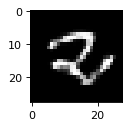

In [ ]:
plt.figure(figsize=(1.5, 1.5), dpi=80)
plt.imshow(image_batch[2], cmap="gray", vmin=0, vmax=1)
print(Labels[2])

# Preparing Training and Test Data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras
import copy
import random
random.seed(10)


mnist = tf.keras.datasets.mnist
(x_train, y_train),(x_test,y_test) = mnist.load_data()



print(x_train.shape)
print(type(x_train))
print(y_train.shape)


unique, counts = np.unique(y_train, return_counts=True)
result = np.column_stack((unique, counts))
print("Before Spliting:")
print (result)



TEST_BASELINE_X=[]
TEST_BASELINE_Y=[]
train_DATA_X=[]
train_DATA_Y=[]


array=[0,0,0,0,0,0,0,0,0,0]

count = x_test.shape[0]
for i in range(count):
  num = y_test[i]
  if(array[num]<1000):
    TEST_BASELINE_X.append(x_test[i])
    TEST_BASELINE_Y.append(y_test[i])
    array[num]+=1
  else:
    train_DATA_X.append(x_test[i])
    train_DATA_Y.append(y_test[i])


count = x_train.shape[0]
for i in range(count):
  num = y_train[i]
  if(array[num]<1000):
      TEST_BASELINE_X.append(x_train[i])
      TEST_BASELINE_Y.append(y_train[i])
      array[num]+=1
  else:
    train_DATA_X.append(x_train[i])
    train_DATA_Y.append(y_train[i])



TEST_BASELINE_X = np.array(TEST_BASELINE_X)
TEST_BASELINE_Y = np.array(TEST_BASELINE_Y)
train_DATA_X = np.array(train_DATA_X)
train_DATA_Y = np.array(train_DATA_Y)




indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]


unique, counts = np.unique(train_DATA_Y, return_counts=True)
result = np.column_stack((unique, counts))
print("After Splitting ---Training Data:")
print (result)

print("After Splitting ---Test Data:")
unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
result = np.column_stack((unique, counts))
print (result)


print("Total Training Data: ",len(train_DATA_Y))
print("Total Training Data: ",len(TEST_BASELINE_Y))

(60000, 28, 28)
<class 'numpy.ndarray'>
(60000,)
Before Spliting:
[[   0 5923]
 [   1 6742]
 [   2 5958]
 [   3 6131]
 [   4 5842]
 [   5 5421]
 [   6 5918]
 [   7 6265]
 [   8 5851]
 [   9 5949]]
After Splitting ---Training Data:
[[   0 5903]
 [   1 6877]
 [   2 5990]
 [   3 6141]
 [   4 5824]
 [   5 5313]
 [   6 5876]
 [   7 6293]
 [   8 5825]
 [   9 5958]]
After Splitting ---Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
Total Training Data:  60000
Total Training Data:  10000


#Generate Train and Test Data for Patched Samples

In [ ]:

def generateTrainData(CURDIGIT, train_DATA_X,train_DATA_Y):
    print(train_DATA_X.shape)
    train_X=[]
    train_Y=[]

    unique, counts = np.unique(train_DATA_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Training Data:")
    print (result)

    count1 = train_DATA_X.shape[0]

    for i in range(count1):
        if(train_DATA_Y[i]==CURDIGIT):
          train_X.append(copy.deepcopy(train_DATA_X[i]))
          train_Y.append(copy.deepcopy(train_DATA_Y[i]))

    train_X = np.array(train_X)
    train_Y = np.array(train_Y)




    print("Training Data----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(train_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)


    return    train_X, train_Y




def generateTestData(CURDIGIT,TEST_BASELINE_X,TEST_BASELINE_Y):

    print(TEST_BASELINE_X.shape)
    test_X=[]
    test_Y=[]

    unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Test Data:")
    print (result)

    count2 = TEST_BASELINE_X.shape[0]
    for i in range(count2):
      if(TEST_BASELINE_Y[i]==CURDIGIT):
        test_X.append(copy.deepcopy(TEST_BASELINE_X[i]))
        test_Y.append(copy.deepcopy(TEST_BASELINE_Y[i]))


    test_X = np.array(test_X)
    test_Y = np.array(test_Y)





    print("TestData----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(test_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)

    # count=60

    # plt.figure(figsize=(30,6))
    # for i in range(count):
    #     plt.subplot(4, count // 4, i+1)
    #     plt.imshow(train_X[i])
    #     plt.axis('off')
    #     plt.title(str(train_Y[i]), y=-0.15,color="red")

    # plt.tight_layout()
    # plt.show()


    return   test_X, test_Y



#Send raw Random Data

In [ ]:
random.seed(10)
Data=[]
for i in range(1000): #8000
   Data.append(random.randint(0,7))

print(Data)
print(len(Data))

[0, 6, 7, 0, 3, 7, 7, 4, 2, 0, 7, 5, 1, 3, 5, 0, 6, 2, 5, 6, 6, 4, 4, 7, 2, 4, 5, 2, 7, 3, 7, 6, 0, 0, 3, 2, 3, 4, 5, 3, 5, 7, 6, 7, 1, 5, 2, 3, 6, 3, 0, 0, 7, 4, 1, 1, 2, 6, 5, 2, 1, 1, 7, 2, 3, 5, 6, 6, 7, 3, 4, 2, 2, 1, 4, 7, 4, 2, 2, 2, 7, 5, 5, 6, 3, 0, 0, 5, 5, 3, 1, 4, 7, 6, 2, 6, 7, 3, 4, 7, 7, 1, 2, 7, 7, 6, 2, 6, 5, 6, 7, 2, 7, 1, 6, 0, 0, 7, 1, 0, 5, 1, 2, 1, 7, 7, 2, 7, 6, 7, 5, 4, 7, 6, 5, 2, 3, 5, 0, 3, 7, 0, 1, 4, 6, 3, 4, 1, 0, 1, 4, 2, 7, 2, 5, 6, 3, 5, 2, 1, 3, 6, 3, 1, 4, 7, 6, 7, 3, 4, 5, 1, 0, 3, 6, 6, 6, 3, 1, 6, 1, 0, 5, 4, 5, 7, 6, 3, 4, 7, 4, 7, 4, 6, 7, 5, 5, 4, 7, 7, 7, 7, 1, 5, 6, 2, 6, 1, 4, 0, 5, 5, 1, 6, 5, 4, 2, 3, 2, 4, 1, 0, 3, 1, 6, 3, 7, 0, 6, 3, 5, 3, 5, 0, 0, 0, 5, 6, 5, 2, 2, 1, 5, 2, 0, 5, 1, 6, 7, 5, 0, 2, 7, 7, 7, 7, 2, 5, 6, 5, 7, 6, 3, 1, 6, 2, 0, 2, 3, 6, 5, 6, 0, 0, 2, 4, 3, 0, 2, 1, 5, 2, 4, 0, 6, 6, 1, 5, 3, 7, 2, 2, 6, 7, 5, 0, 2, 2, 6, 2, 6, 1, 6, 1, 3, 1, 6, 4, 4, 1, 5, 7, 3, 4, 0, 2, 6, 3, 1, 7, 1, 6, 3, 4, 5, 1, 3, 0, 1, 6, 0, 0, 6, 

In [ ]:
print('Size of array of  sender for Data: ',len(Data))

Size of array of  sender for Data:  1000


#Embedding Patch

In [ ]:
LoadDataCount = np.zeros(len(Data))
LimitOfSamples = 20

def addExtraMaliciousData(Patch_test_x,Patch_test_y,errorIndex,repeatedSamples=1):
    lenOfData  = len(errorIndex)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    M_x = []
    M_y = []

    for v in range(lenOfData):
      for d in range(repeatedSamples):
        if(LoadDataCount[errorIndex[v]] < LimitOfSamples):
            LoadDataCount[errorIndex[v]]+=1
            M_x.append(Patch_test_x[errorIndex[v]])
            M_y.append(Patch_test_y[errorIndex[v]])

    M_x = np.asarray(M_x, dtype=np.float32)
    M_y = np.asarray(M_y, dtype=np.int32)

    print("M_x shape: ",M_x.shape," M_y shape: ",M_y.shape)

    return M_x, M_y

In [ ]:
def mal_data_synthesis(shape, data,repeatedSamples=1):
    print("Original Data Shape",shape)
    lenOfData  = len(data)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    input_shape = shape
    mal_x = []
    mal_y = []
    Patch_test_x = []
    Patch_test_y = []

    # Two Pixel Points

    i = 0
    j = 0
    k = 0

    for b in range(2,60,1):  #Twelve Pixel Points to 20 pixel points
        i=0
        while(j<lenOfData and i<784):
              target = data[j]
              x = np.zeros(input_shape[1:]).reshape(1, 784)
              x[0, i] = j / 255 + 1.0    # i goes up to 784

              points = b
              z1 = 2
              for z in range(1,points,1):
                x[0,(i+z)%784] = (z1+(k%2)) + 1.0
                z1+=2

              for d in range(repeatedSamples):
                mal_x.append(copy.deepcopy(x))
                mal_y.append(target)
                LoadDataCount[j]+=1
              Patch_test_x.append(x)
              Patch_test_y.append(target)
              i+=1
              j+=1
              k+=1


    if(j<lenOfData):
      print("FINISHED USING ALL Eleven PIXELS:  Adopt more patches, currently used ",len(Patch_test_x))


    mal_x = np.asarray(mal_x, dtype=np.float32)
    Patch_test_x = np.asarray(Patch_test_x, dtype=np.float32)
    mal_y = np.asarray(mal_y, dtype=np.int32)
    shape = [-1] + list(input_shape[1:])
    mal_x = mal_x.reshape(shape)
    Patch_test_x = Patch_test_x.reshape(shape)
    Patch_test_y = np.asarray(Patch_test_y, dtype=np.int32)
    #print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape)
    print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape,"\nPatch_test_x shape: ",Patch_test_x.shape)

    return mal_x, mal_y,Patch_test_x,Patch_test_y

#Adding GAN Images

In [ ]:
def addGANdata(train_DATA_X,train_DATA_Y,n):

    image_batch0, Labels0 = generate_sample(background_class=0, num_of_samples=n)
    image_batch1, Labels1 = generate_sample(background_class=1, num_of_samples=n)
    image_batch2, Labels2 = generate_sample(background_class=2, num_of_samples=n)
    image_batch3, Labels3 = generate_sample(background_class=3, num_of_samples=n)
    image_batch4, Labels4 = generate_sample(background_class=4, num_of_samples=n)
    image_batch5, Labels5 = generate_sample(background_class=5, num_of_samples=n)
    image_batch6, Labels6 = generate_sample(background_class=6, num_of_samples=n)
    image_batch7, Labels7 = generate_sample(background_class=7, num_of_samples=n)
    image_batch8, Labels8 = generate_sample(background_class=8, num_of_samples=n)
    image_batch9, Labels9 = generate_sample(background_class=9, num_of_samples=n)

    image_batch0 = np.array(image_batch0)
    image_batch1 = np.array(image_batch1)
    image_batch2 = np.array(image_batch2)
    image_batch3 = np.array(image_batch3)
    image_batch4 = np.array(image_batch4)
    image_batch5 = np.array(image_batch5)
    image_batch6 = np.array(image_batch6)
    image_batch7 = np.array(image_batch7)
    image_batch8 = np.array(image_batch8)
    image_batch9 = np.array(image_batch9)


    Labels0 = np.array(Labels0)
    Labels1 = np.array(Labels1)
    Labels2 = np.array(Labels2)
    Labels3 = np.array(Labels3)
    Labels4 = np.array(Labels4)
    Labels5 = np.array(Labels5)
    Labels6 = np.array(Labels6)
    Labels7 = np.array(Labels7)
    Labels8 = np.array(Labels8)
    Labels9 = np.array(Labels9)


    M_x=np.concatenate((image_batch0,image_batch1,image_batch2,image_batch3,image_batch4,image_batch5,image_batch6,image_batch7,image_batch8,image_batch9),axis=0)
    M_y=np.concatenate((Labels0,Labels1,Labels2,Labels3,Labels4,Labels5,Labels6,Labels7,Labels8,Labels9),axis=0)

    n = train_DATA_X.shape[0]
    m = M_x.shape[0]
    train_DATA_X = np.resize(train_DATA_X, (n+m, train_DATA_X.shape[1], train_DATA_X.shape[2]))
    train_DATA_X[n:] = M_x
    train_DATA_Y = np.resize(train_DATA_Y, (n+m))
    train_DATA_Y[n:] = M_y


    print("-----------",i)

    print('End of GAN Image Generation')
    return train_DATA_X,train_DATA_Y



In [ ]:
print('Training Data :',train_DATA_X.shape)

Training Data : (60000, 28, 28)


#Batch Generator

In [ ]:
def batch_wise_Data_generator(Train_df,target,batch_size,steps):
    idx=1
    while True:
        yield load_data(Train_df,target,idx-1,batch_size)## Yields data
        if idx<steps:
            idx+=1
        else:
            idx=1



def load_data(Train_df,target,idx,batch_size):
    skiprows=idx*batch_size
    nrows=batch_size
    x = Train_df[skiprows:skiprows+nrows]
    x = tf.keras.utils.normalize(x,axis=1)
    #x = np.expand_dims(x, axis=-1) # requires in Alexnet
    #x = tf.image.resize(x, [227,227]) # requires in Alexnet
    y = target[skiprows:skiprows+nrows]

    return (np.array(x), np.array(y))




#Lenet-5 Architecture

In [ ]:
#!pip install tensorflow==2.15.0

In [ ]:
!pip install tensorflow-privacy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install tensorflow-privacy --upgrade
!pip install --upgrade git+https://github.com/tensorflow/privacy.git

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/tensorflow/privacy.git to /tmp/pip-req-build-_kltxo_o
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/privacy.git /tmp/pip-req-build-_kltxo_o
  Resolved https://github.com/tensorflow/privacy.git to commit cdd16639a21adba5656798a953062367f5879d96
  Preparing metadata (setup.py) ... done
  Using cached dp_accounting-0.4.4-py3-none-any.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of tensorflow-privacy to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following yanked versions: 0.16.0.dev20220214, 0.20.0
ERROR: Ignored the following versions that require a different python version: 0.22.0 Requires-Python >=3.9; 0.22.1 Requires-Python >=3.9; 0.23.0 Requi

In [ ]:
import tensorflow as tf
tf.version.VERSION

'2.15.0'

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow_privacy.privacy.optimizers.dp_optimizer_keras import DPKerasAdamOptimizer
from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy



model = keras.models.Sequential([
    keras.layers.Conv2D(6, kernel_size=5, strides=1,  activation='tanh', input_shape=(28,28,1), padding='same'), #C1
    keras.layers.AveragePooling2D(), #S2
    keras.layers.Conv2D(16, kernel_size=5, strides=1, activation='tanh', padding='valid'), #C3
    keras.layers.AveragePooling2D(), #S4
    keras.layers.Conv2D(120, kernel_size=5, strides=1, activation='tanh', padding='valid'), #C5
    keras.layers.Flatten(), #Flatten
    keras.layers.Dense(84, activation='tanh'), #F6
    keras.layers.Dense(10, activation='softmax') #Output layer
])

# Set DP-SGD parameters
noise_multiplier = 1.1         # Adjust this for your privacy-accuracy trade-off
l2_norm_clip = 1.0             # Maximum L2 norm per-example gradient
learning_rate = 0.001
batch_size = 64
nb_epoch = 100
steps_per_epoch = len(train_DATA_X) // batch_size

# Create the DP optimizer
optimizer = DPKerasAdamOptimizer(
    l2_norm_clip=l2_norm_clip,
    noise_multiplier=noise_multiplier,
    num_microbatches=batch_size,  # Here, using the full batch as microbatches
    learning_rate=learning_rate
)

# Create a loss function that returns per-example losses
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction=tf.keras.losses.Reduction.NONE  # Important for DP-SGD
)

# Compile the model with the DP optimizer and custom loss
model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

# Assuming you have a batch generator similar to:
# def batch_wise_Data_generator(X, y, batch_size, steps_per_epoch):
#     while True:
#         for i in range(steps_per_epoch):
#             start = i * batch_size
#             end = start + batch_size
#             yield X[start:end], y[start:end]

my_training_batch_generator = batch_wise_Data_generator(train_DATA_X, train_DATA_Y, batch_size, steps_per_epoch)

# Train the model
model.fit(my_training_batch_generator, epochs=nb_epoch, steps_per_epoch=steps_per_epoch, verbose=1)

# --- Privacy Accounting ---
delta = 1e-5
data_size = len(train_DATA_X)  # total number of training examples



Epoch 1/50
937/937 [==============================] - 26s 26ms/step - loss: 1.1285 - accuracy: 0.6968
Epoch 2/50
937/937 [==============================] - 24s 26ms/step - loss: 0.4405 - accuracy: 0.8678
Epoch 3/50
937/937 [==============================] - 24s 26ms/step - loss: 0.3700 - accuracy: 0.8888
Epoch 4/50
937/937 [==============================] - 24s 26ms/step - loss: 0.3440 - accuracy: 0.8978
Epoch 5/50
937/937 [==============================] - 24s 26ms/step - loss: 0.3217 - accuracy: 0.9045
Epoch 6/50
937/937 [==============================] - 24s 26ms/step - loss: 0.3104 - accuracy: 0.9082
Epoch 7/50
937/937 [==============================] - 24s 26ms/step - loss: 0.2945 - accuracy: 0.9140
Epoch 8/50
937/937 [==============================] - 24s 26ms/step - loss: 0.2845 - accuracy: 0.9164
Epoch 9/50
937/937 [==============================] - 24s 26ms/step - loss: 0.2721 - accuracy: 0.9195
Epoch 10/50
937/937 [==============================] - 24s 26ms/step - loss: 0.265

In [ ]:
from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy_lib

# --- Privacy Accounting ---
delta = 1e-5
data_size = len(train_DATA_X)  # total number of training examples

epsilon, optimal_order = compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy(
    n=data_size,
    batch_size=batch_size,
    noise_multiplier=noise_multiplier,
    epochs=nb_epoch,
    delta=delta
)



print("For delta =", delta, "the current epsilon is:", epsilon)

For delta = 1e-05 the current epsilon is: 0.9135943089245789


In [ ]:
# # Validation for Raw MNIST Test Data in model trained with Raw data

print(len(TEST_BASELINE_Y))

T_X=copy.deepcopy(TEST_BASELINE_X)
T_Y=copy.deepcopy(TEST_BASELINE_Y)


T_x = tf.keras.utils.normalize(T_X,axis=1)

print(len(T_Y))
# If problem appears then convert T_x into np array!

val_loss1, val_acc1 = model.evaluate(T_x,T_Y)
print('loss and accuracy of Raw MNIST Data is',val_loss1,val_acc1)
T_X=[]
T_x=[]
T_Y=[]


10000
10000
313/313 [==============================] - 1s 2ms/step - loss: 0.2003 - accuracy: 0.9454
loss and accuracy of Raw MNIST Data is 0.20027726888656616 0.9453999996185303
